In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

## Chapter 02b — Surfaces, Contours & Vector Fields

Many objects in machine learning are functions of **two** variables, like a
loss surface $L(w_1, w_2)$. This notebook shows the standard ways to picture a
function $f(x, y)$ and a vector field, all built on one key idea: the **grid**.

___
### 1. The grid: `np.meshgrid`

To evaluate $f(x, y)$ over a rectangle we need every combination of an $x$ and
a $y$. `np.meshgrid` takes a 1D list of $x$ values and a 1D list of $y$ values
and returns two 2D arrays `X` and `Y` such that `(X[i,j], Y[i,j])` is one grid
point. Then a vectorised formula gives `Z = f(X, Y)` for the whole grid at once.

In [3]:
# A small grid so we can SEE the arrays.
xs = np.linspace(0, 2, 3)   # [0, 1, 2]
ys = np.linspace(0, 1, 2)   # [0, 1]
X, Y = np.meshgrid(xs, ys)

print("X =\n", X)   # x-coordinate at each grid point
print("Y =\n", Y)   # y-coordinate at each grid point
print("X + Y =\n", X + Y) 

X =
 [[0. 1. 2.]
 [0. 1. 2.]]
Y =
 [[0. 0. 0.]
 [1. 1. 1.]]
X + Y =
 [[0. 1. 2.]
 [1. 2. 3.]]


___
So the grid contains:

`(0,0), (1,0), (2,0), (0,1), (1,1), (2,1)`

**Purpose:** create all `(x, y)` points needed to evaluate `f(x, y)` across a region.

____
### 2. A function of two variables

Let
$$f(x, y) = \exp\!\big(-(x^2 + y^2)\big),$$
a smooth "bump" centered at the origin. We build a fine grid and evaluate it.

In [4]:
xs = np.linspace(-2, 2, 200)
ys = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(xs, ys)

Z = np.exp(-(X ** 2 + Y ** 2))   # f(x, y) on the whole grid at once
print("Z has shape", Z.shape)   # one value per grid point

Z has shape (200, 200)


____
### 3. Contour lines: `plt.contour`

A **contour line** connects points where $f$ has the same value — exactly like
height lines on a topographic map. Closely-spaced contours mean a steep region.

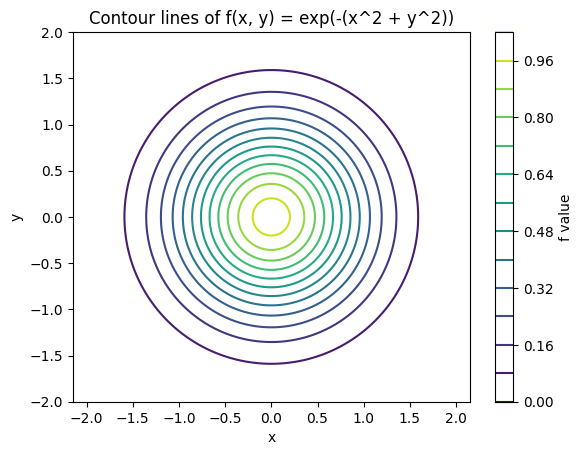

In [5]:
plt.contour(X, Y, Z, levels=12)   # 12 evenly spaced level curves
plt.title("Contour lines of f(x, y) = exp(-(x^2 + y^2))")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")        # equal scaling so circles look like circles
plt.colorbar(label="f value")
plt.show()

* **Each line:** every point along each circle has the same `f` value (all pts on yellow circle has `f` = 0.96)
* **Lines close together:** `f` changes rapidly → **steep**.
* **Lines far apart:** `f` changes slowly → **gentle**.


____
### 4. Filled contours: `plt.contourf`

`contourf` (the **f** is for *filled*) shades the bands between contours, which
reads more like a heat map. A colorbar decodes color into value.

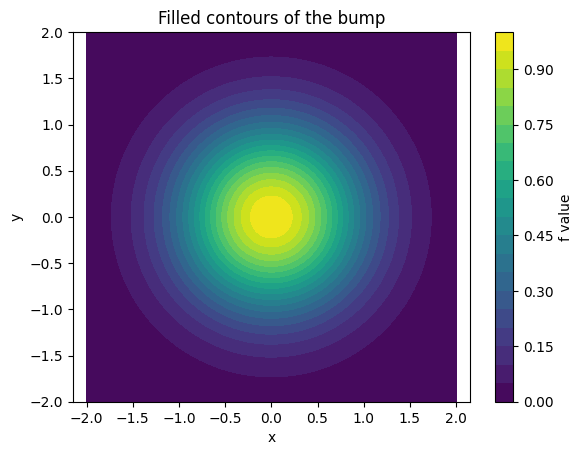

In [6]:
plt.contourf(X, Y, Z, levels=20, cmap="viridis")
plt.title("Filled contours of the bump")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.colorbar(label="f value")
plt.show()

____
### 5. A 3D surface: `ax.plot_surface`

The same `X, Y, Z` can be drawn as a true surface. 3D drawing needs an axes
created with `projection="3d"`. (Behind the scenes this uses
`mpl_toolkits.mplot3d`; modern Matplotlib enables it automatically when you ask
for the 3D projection.)

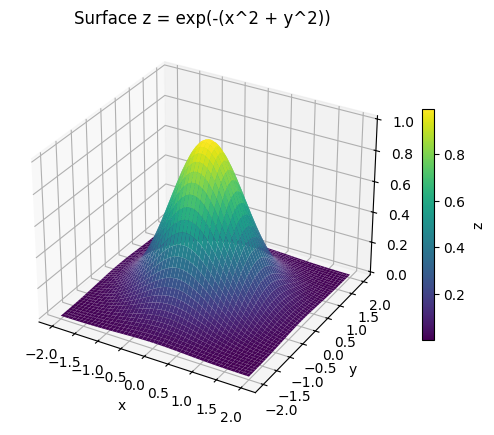

In [7]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")   # make a 3D axes

# Draw the surface; cmap colors it by height.
surf = ax.plot_surface(X, Y, Z, cmap="viridis")

ax.set_title("Surface z = exp(-(x^2 + y^2))")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
fig.colorbar(surf, shrink=0.6, label="z")
plt.show()

A contour plot is really this surface viewed straight from above. Contours are
cheap, exact, and easy to read; the 3D view is good for an intuitive first look.

____
### 6. A vector field: `plt.quiver` (gradients)

A **vector field** attaches an arrow to each point. A natural example is the
**gradient** $\nabla f = \left(\dfrac{\partial f}{\partial x},
\dfrac{\partial f}{\partial y}\right)$, which points in the direction of
steepest increase. For our bump,
$$\nabla f = \big(-2x\,f,\; -2y\,f\big).$$
We compute it on a *coarse* grid (too many arrows is unreadable) and draw it
with `quiver`.

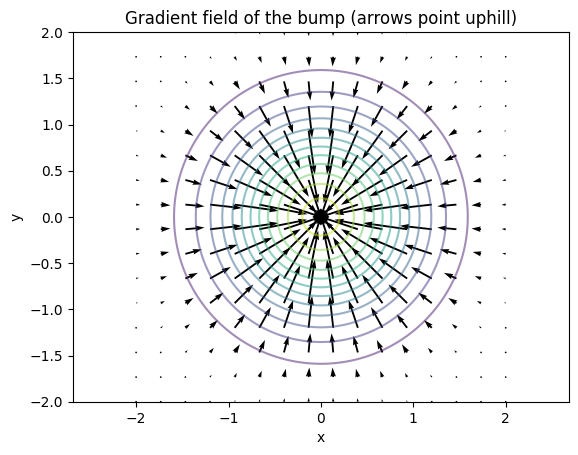

In [8]:
# Coarse grid just for the arrows.
xs = np.linspace(-2, 2, 16)   # 16 × 16 → 256 arrow positions  ← coarse, readable
ys = np.linspace(-2, 2, 16)
Xc, Yc = np.meshgrid(xs, ys)
Fc = np.exp(-(Xc**2 + Yc**2))

U = -2 * Xc * Fc    # df/dx  ->  diff Fc by x to get U
V = -2 * Yc * Fc    # df/dy

plt.figure()                                  # fresh 2D figure
plt.contour(X, Y, Z, levels=12, alpha=0.5)   # contours for context
plt.quiver(Xc, Yc, U, V, color="black")       # arrows = gradient
plt.title("Gradient field of the bump (arrows point uphill)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

### `U` and `V`

For \(F(x,y)=e^{-(x^2+y^2)}\):

$$
U=\frac{\partial F}{\partial x}=-2xF
$$

→ **horizontal change**

$$
V=\frac{\partial F}{\partial y}=-2yF
$$

→ **vertical change**

* **So: `(Xc, Yc)` = where the arrow is,**

* **`(U, V)` = which way it points and how large it is.**

Notice the arrows all point **inward toward the peak** at the origin and shrink
to nothing far away, where the bump is flat. Following them uphill is exactly
what *gradient ascent* does.

____
### 7. Heatmap of a matrix: `plt.imshow`

`imshow` draws a 2D array as a grid of colored pixels — perfect for visualising
a matrix. Each entry becomes one colored cell; `colorbar` gives the scale.

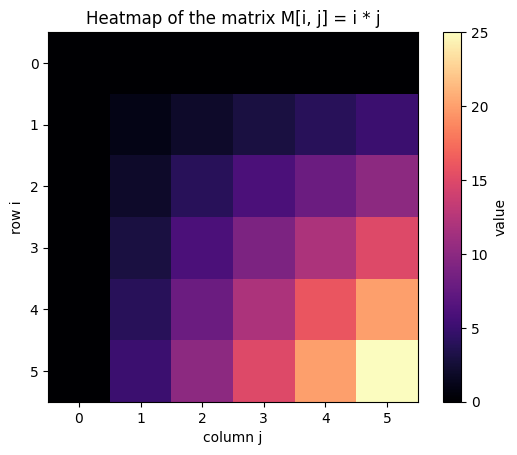

In [9]:
# A 6x6 matrix whose entry (i, j) is i * j (a multiplication table).
i = np.arange(6).reshape(6, 1)   # column 0..5
j = np.arange(6).reshape(1, 6)   # row    0..5
M = i * j                        # outer product via broadcasting

plt.imshow(M, cmap="magma")
plt.title("Heatmap of the matrix M[i, j] = i * j")
plt.xlabel("column j")
plt.ylabel("row i")
plt.colorbar(label="value")
plt.show()

---
### ✍️ Exercise 1 (solution included)

Build a grid on $[-3, 3] \times [-3, 3]$ and draw **filled contours** of the
saddle function
$$f(x, y) = x^2 - y^2.$$
Add a colorbar and axis labels. (You should see a saddle: high along the
$x$-axis, low along the $y$-axis.)

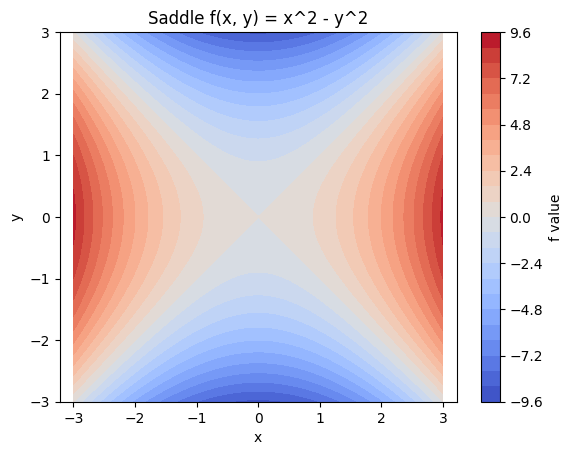

In [10]:
xs = np.linspace(-3, 3, 200)
ys = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(xs, ys)
Z = (X**2) - (Y**2)          # the saddle

plt.contourf(X, Y, Z, levels=25, cmap="coolwarm")
plt.title("Saddle f(x, y) = x^2 - y^2")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.colorbar(label="f value")
plt.show()

**Warm** colors represent **+ve** values; **blue** represent **-ve** values

             y
             ↑
          LOW
             |
             |
  HIGH ←─────0─────→ HIGH
             |
             |
          LOW

____
### ✍️ Exercise 2 (solution included)

For the same saddle $f(x, y) = x^2 - y^2$, draw its gradient field with
`quiver` on a coarse $15 \times 15$ grid. The gradient is
$$\nabla f = (2x,\; -2y).$$
Overlay it on the contour lines for context.

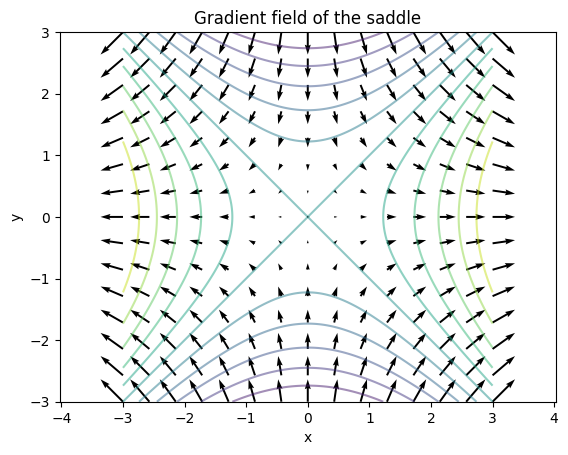

In [18]:
# Fine grid for contours.
xf = np.linspace(-3, 3, 200)
Xf, Yf = np.meshgrid(xf, xf)

Zf = (Xf **2 ) - (Yf ** 2)

# Coarse grid for arrows.
xc = np.linspace(-3, 3, 15)
Xc, Yc = np.meshgrid(xc, xc)

U = 2 * Xc      # df/dx
V = -2 * Yc     # df/dy

plt.contour(Xf, Yf, Zf, levels=15, alpha=0.5)
plt.quiver(Xc, Yc, U, V, color="black")
plt.title("Gradient field of the saddle")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

---
### 📝 Homework (no solutions provided)

1. Plot filled contours of $f(x, y) = \sin(x)\cos(y)$ on
   $[-\pi, \pi] \times [-\pi, \pi]$. Add a colorbar.

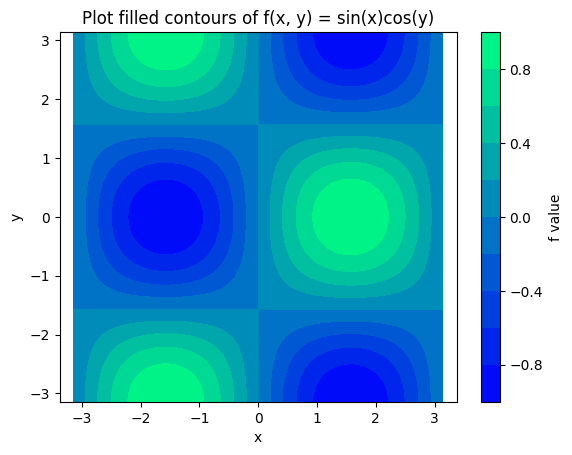

In [26]:
x = np.linspace(-1 * np.pi, np.pi, 200)
y = np.linspace(-1 * np.pi, np.pi, 200)
X, Y = np.meshgrid(x, y)

Z = (np.sin(X)) * (np.cos(Y))

plt.contourf(X, Y, Z, levels=12, cmap="winter") #cmap
plt.title("Plot filled contours of f(x, y) = sin(x)cos(y)")
plt.xlabel("x"); plt.ylabel("y")
plt.axis("equal")
plt.colorbar(label="f value")
plt.show()